# KELOMPOK 5

### Pemodelan dan Analisis Data Persetujuan Pinjaman untuk Mendukung Keputusan Kredit

Notebook ini bertujuan untuk melakukan analisis terhadap data persetujuan pinjaman guna mendukung pengambilan keputusan kredit. Analisis dilakukan melalui beberapa tahapan sebagai berikut:

1. **Mencari Approval Rate dari Tiap Baris Data**  
   Pada tahap ini, kami menghitung rasio persetujuan pinjaman berdasarkan masing-masing data yang tersedia. Rasio ini dapat memberikan gambaran seberapa besar kemungkinan pinjaman disetujui berdasarkan karakteristik tertentu dari pemohon.

2. **Mengelompokkan Data dan Menganalisis Hasil Pengelompokkan**  
   Data pemohon akan dikelompokkan menggunakan metode clustering seperti K-Means. Tujuannya adalah untuk mengidentifikasi pola atau segmen pemohon berdasarkan fitur-fitur tertentu. Hasil pengelompokkan ini akan dianalisis untuk menemukan cluster yang memiliki tingkat persetujuan tinggi maupun rendah.

Proses ini diharapkan dapat membantu dalam membuat keputusan kredit yang lebih tepat dan berbasis data.


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving loan_data.csv to loan_data.csv


### Data Collection

In [ ]:
import pandas as pd
df = pd.read_csv('loan_data.csv')

## Impor Library


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler

# CRISP DM

## Data Understanding

### Pemeriksaan Awal
Menampilkan struktur data, tipe data, dan ringkasan awal.


In [ ]:
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24000 entries, 0 to 23999
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Text               24000 non-null  object 
 1   Income             24000 non-null  int64  
 2   Credit_Score       24000 non-null  int64  
 3   Loan_Amount        24000 non-null  int64  
 4   DTI_Ratio          24000 non-null  float64
 5   Employment_Status  24000 non-null  object 
 6   Approval           24000 non-null  object 
dtypes: float64(1), int64(3), object(3)
memory usage: 1.3+ MB


,Income,Credit_Score,Loan_Amount,DTI_Ratio
count,24000.000000,24000.000000,24000.000000,24000.000000
mean,110377.552708,575.720333,44356.154833,34.719167
std,51729.677627,159.227621,34666.604785,32.322471
min,20001.000000,300.000000,1005.000000,2.530000
25%,65635.750000,437.000000,16212.000000,14.507500
50%,110464.000000,575.000000,35207.000000,24.860000
75%,155187.000000,715.000000,65622.750000,41.840000
max,200000.000000,850.000000,158834.000000,246.330000


### VISUALISASI DATA

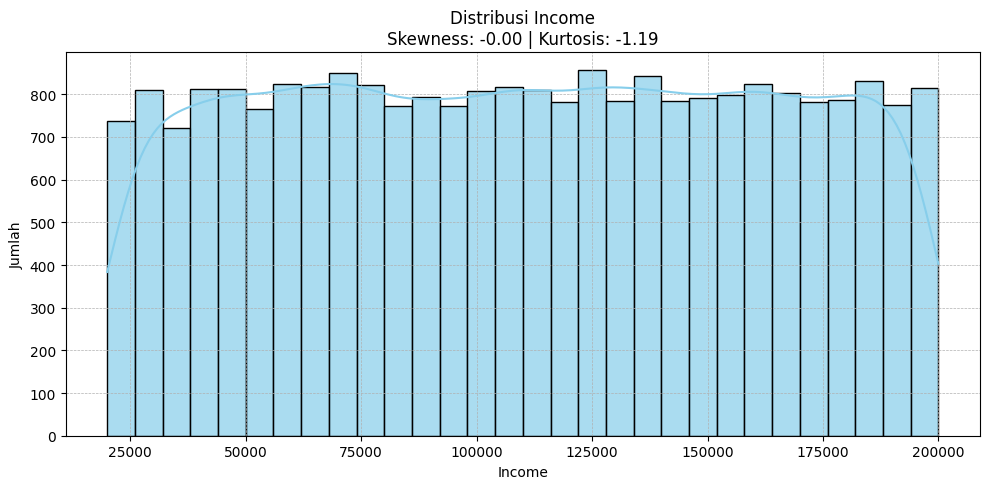

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Hitung skewness dan kurtosis untuk informasi tambahan
skewness = df['Income'].skew()
kurtosis = df['Income'].kurt()

# Visualisasi distribusi Income
plt.figure(figsize=(10, 5))
sns.histplot(df['Income'], bins=30, kde=True, color='skyblue', edgecolor='black', alpha=0.7)
plt.title(f'Distribusi Income\nSkewness: {skewness:.2f} | Kurtosis: {kurtosis:.2f}')
plt.xlabel('Income')
plt.ylabel('Jumlah')
plt.grid(True, linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()


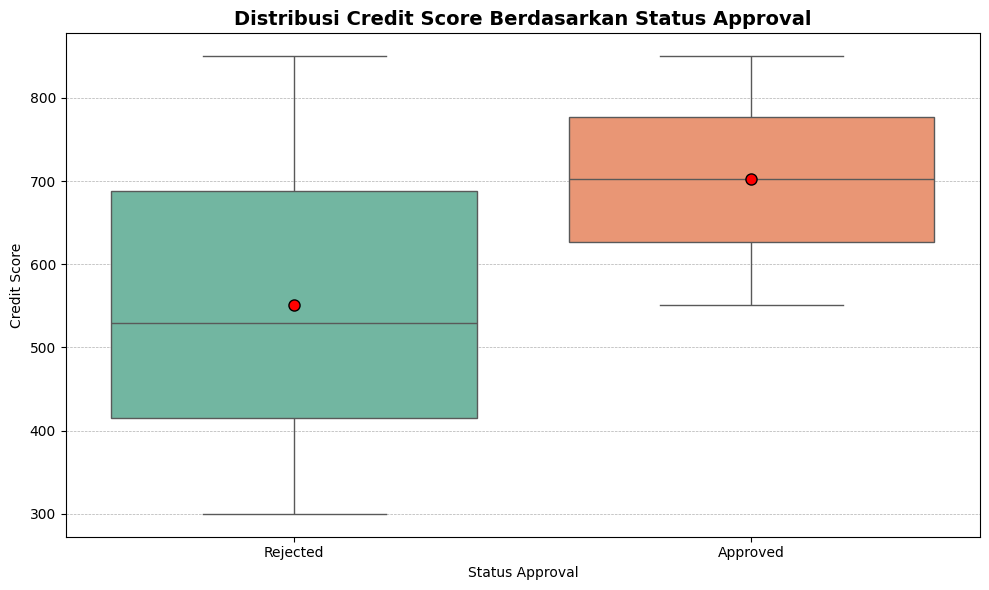

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Approval', y='Credit_Score', hue='Approval', data=df,
            palette='Set2', showmeans=True, legend=False,
            meanprops={"marker":"o", "markerfacecolor":"red", "markeredgecolor":"black", "markersize":"8"})
plt.title('Distribusi Credit Score Berdasarkan Status Approval', fontsize=14, fontweight='bold')
plt.xlabel('Status Approval')
plt.ylabel('Credit Score')
plt.grid(axis='y', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

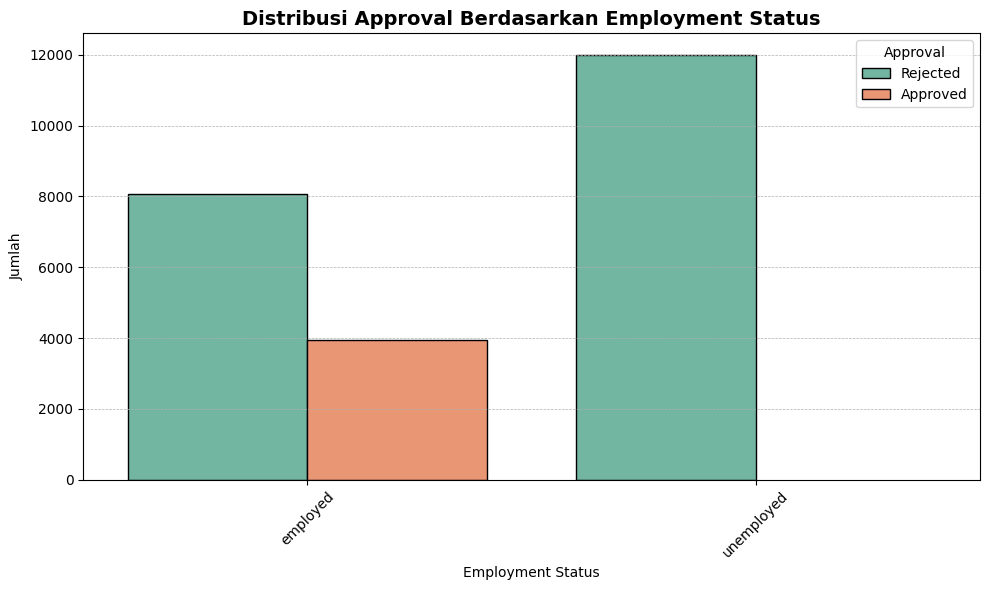

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(
    x='Employment_Status',
    hue='Approval',
    data=df,
    palette='Set2',
    edgecolor='black'
)
plt.title('Distribusi Approval Berdasarkan Employment Status', fontsize=14, fontweight='bold')
plt.xlabel('Employment Status')
plt.ylabel('Jumlah')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', linewidth=0.5)
plt.legend(title='Approval')
plt.tight_layout()
plt.show()

## Evaluasi Data Understanding
###📌 1. Pemeriksaan Awal Dataset
✅ Positif:

Penggunaan df.info() dan df.describe() tepat untuk memahami struktur dan statistik dasar data.

#### Tipe data dan missing values sudah diperiksa.

#### 🛠️ Saran Perbaikan:

Kolom Text, Approval, dan Employment_Status bertipe object, pastikan nanti dilakukan encoding (label encoding/one-hot) jika akan digunakan untuk modeling.

Kolom Text belum dijelaskan, jika tidak relevan untuk analisis sebaiknya dihapus lebih awal.

### 📊 2. Visualisasi Data
Distribusi Income (sns.histplot):

✅ Histogram dan KDE membantu melihat sebaran Income yang tampak cukup merata (tidak terlalu skewed).

Credit Score berdasarkan Approval (sns.boxplot):

✅ Sangat informatif, memperlihatkan bahwa Approved cenderung memiliki nilai Credit_Score lebih tinggi dari Rejected.

Loan Amount vs DTI Ratio (sns.scatterplot):

✅ Visualisasi bagus, terlihat korelasi negatif antara Loan_Amount dan DTI_Ratio.

Approval berdasarkan Employment Status (sns.countplot):

✅ Insight yang jelas: unemployed memiliki lebih sedikit approval.

### ❌ 3. Missing Values
✅ Sudah dicek dengan df.isnull().sum(), hasilnya semua kolom tidak memiliki missing values.

🟢 Tidak ada masalah pada tahap ini.

### 🧠 Kesimpulan Evaluasi Awal
Secara umum, EDA sudah mencakup struktur data, distribusi, dan hubungan antar variabel.

## DATA PREPARATION

### Cek Missing Values

In [ ]:
print(">> Jumlah Missing Values per Kolom:")
print(df.isnull().sum())

>> Jumlah Missing Values per Kolom:
Text                 0
Income               0
Credit_Score         0
Loan_Amount          0
DTI_Ratio            0
Employment_Status    0
Approval             0
dtype: int64


In [ ]:
# Tangani missing values dan missing data
missing_cols = df.columns[df.isnull().any()]
for col in missing_cols:
    if df[col].dtype in ['int64', 'float64']:
        df[col] = df[col].fillna(df[col].mean())
        print(f">> Missing pada '{col}' telah diisi dengan mean.")
    else:
        df[col] = df[col].fillna(df[col].mode()[0])
        print(f">> Missing pada '{col}' telah diisi dengan mode.")

# Tampilkan jumlah duplikat dan hapus jika ada
print(">> Jumlah data duplikat:", df.duplicated().sum())
df = df.drop_duplicates()
print(">> Duplikat telah dihapus (jika ada).")

>> Jumlah data duplikat: 0
>> Duplikat telah dihapus (jika ada).


In [ ]:
#Tangani missing values
if df['Income'].isnull().sum() > 0:
    df['Income'] = df['Income'].fillna(df['Income'].mean())
    print("\n>> Missing pada 'Income' telah diisi dengan mean.")

### Cek dan Hapus Duplikat

In [ ]:
print(">> Jumlah data duplikat:", df.duplicated().sum())
df = df.drop_duplicates()
print(">> Duplikat telah dihapus (jika ada).")

>> Jumlah data duplikat: 0
>> Duplikat telah dihapus (jika ada).


### Koreksi Tipe Data

In [ ]:
df.loc[:, 'Income'] = df['Income'].astype(float)
print("\n>> Tipe data 'Income' berhasil dikonversi ke float tanpa peringatan.")


>> Tipe data 'Income' berhasil dikonversi ke float tanpa peringatan.


### Normalisasi Kolom Numerik

In [ ]:
scaler = StandardScaler()
df[['Income', 'Credit_Score', 'Loan_Amount', 'DTI_Ratio']] = scaler.fit_transform(
    df[['Income', 'Credit_Score', 'Loan_Amount', 'DTI_Ratio']]
)

print("\n>> Normalisasi selesai untuk kolom numerik:")
print(df[['Income', 'Credit_Score', 'Loan_Amount', 'DTI_Ratio']].head())


>> Normalisasi selesai untuk kolom numerik:
     Income  Credit_Score  Loan_Amount  DTI_Ratio
0 -1.620410      0.033159    -1.039701   1.378043
1  1.682134     -1.172687     1.939886  -0.389185
2 -1.272344     -0.331107    -0.295338   0.331690
3  1.546252      0.962665     2.146227  -0.757977
4 -0.938060      0.981506    -0.725386   0.291161


### One-hot encoding Employment_Status dan Approval Rate

In [ ]:
# Salin dataframe agar tidak merusak data asli
data = df.copy()

# Konversi 'Approval' dari string jadi numerik
data['Approval'] = data['Approval'].map({'Approved': 1, 'Rejected': 0})

# Encode kolom kategorikal
data = pd.get_dummies(data, columns=['Employment_Status'], drop_first=True)

print(">> Encoding selesai. Kolom sekarang:")
print(data.columns.tolist())


>> Encoding selesai. Kolom sekarang:
['Text', 'Income', 'Credit_Score', 'Loan_Amount', 'DTI_Ratio', 'Approval', 'Employment_Status_unemployed']


### Feature Engineering (Membuat ApprovalRate)

In [ ]:
# Konversi 'Approved' menjadi 1, 'Rejected' menjadi 0
df['Approval'] = df['Approval'].map({'Approved': 1, 'Rejected': 0})

# Sekarang bisa hitung ApprovalRate
df['ApprovalRate'] = df.groupby('Credit_Score')['Approval'].transform('mean')

print(">> Kolom 'ApprovalRate' berhasil ditambahkan:")
print(df[['Credit_Score', 'Approval', 'ApprovalRate']].head())

>> Kolom 'ApprovalRate' berhasil ditambahkan:
   Credit_Score  Approval  ApprovalRate
0      0.033159         0      0.147059
1     -1.172687         0      0.000000
2     -0.331107         0      0.000000
3      0.962665         0      0.250000
4      0.981506         1      0.439024


### Deteksi dan Tangani Outlier


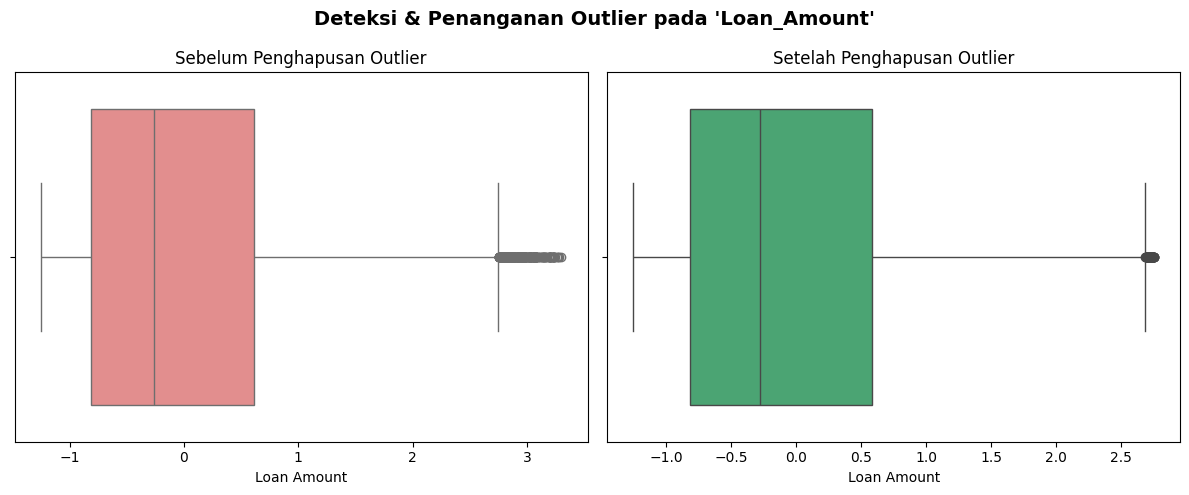

>> Outlier berdasarkan 'Loan_Amount' telah dihapus.
>> Jumlah data awal: 24000, setelah dibersihkan: 23775


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# --- Visualisasi Boxplot Sebelum dan Sesudah Penghapusan Outlier ---
plt.figure(figsize=(12, 5))

# Boxplot sebelum penghapusan outlier
plt.subplot(1, 2, 1)
sns.boxplot(x=df['Loan_Amount'], color='lightcoral')
plt.title("Sebelum Penghapusan Outlier")
plt.xlabel('Loan Amount')

# --- Hitung batas outlier dengan metode IQR ---
Q1 = df['Loan_Amount'].quantile(0.25)
Q3 = df['Loan_Amount'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# --- Hapus outlier dan buat salinan data yang sudah dibersihkan ---
df_cleaned = df[(df['Loan_Amount'] >= lower_bound) & (df['Loan_Amount'] <= upper_bound)].copy()

# Boxplot setelah penghapusan outlier
plt.subplot(1, 2, 2)
sns.boxplot(x=df_cleaned['Loan_Amount'], color='mediumseagreen')
plt.title("Setelah Penghapusan Outlier")
plt.xlabel('Loan Amount')

plt.suptitle("Deteksi & Penanganan Outlier pada 'Loan_Amount'", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f">> Outlier berdasarkan 'Loan_Amount' telah dihapus.")
print(f">> Jumlah data awal: {len(df)}, setelah dibersihkan: {len(df_cleaned)}")


>> Skewness 'DTI_Ratio' setelah normalisasi: 2.34
>> Skewness 'Income' setelah normalisasi: 0.00

--- Menangani Outlier pada 'DTI_Ratio' ---
Menggunakan metode IQR untuk 'DTI_Ratio' (skewness: 2.34)
>> Outlier 'DTI_Ratio' berdasarkan IQR dihapus.
>> Batas IQR: (-1.90, 1.51)
>> Jumlah data sebelum: 23775, setelah: 21899, dihapus: 1876


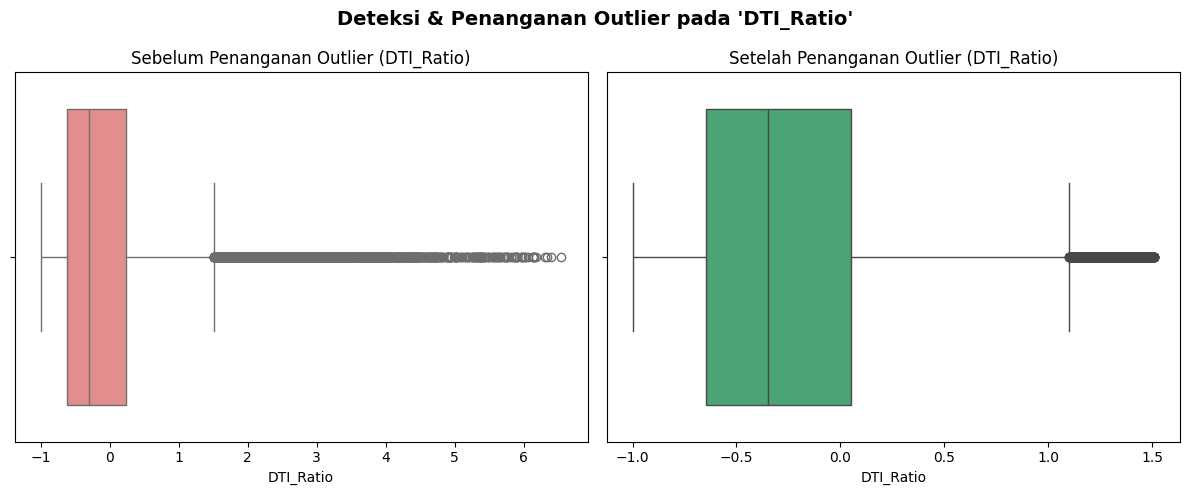


--- Menangani Outlier pada 'Income' ---
Menggunakan metode Z-score untuk 'Income' (skewness: -0.05)
>> Outlier 'Income' berdasarkan Z-score (3) dihapus.
>> Jumlah data sebelum: 21899, setelah: 21899, dihapus: 0


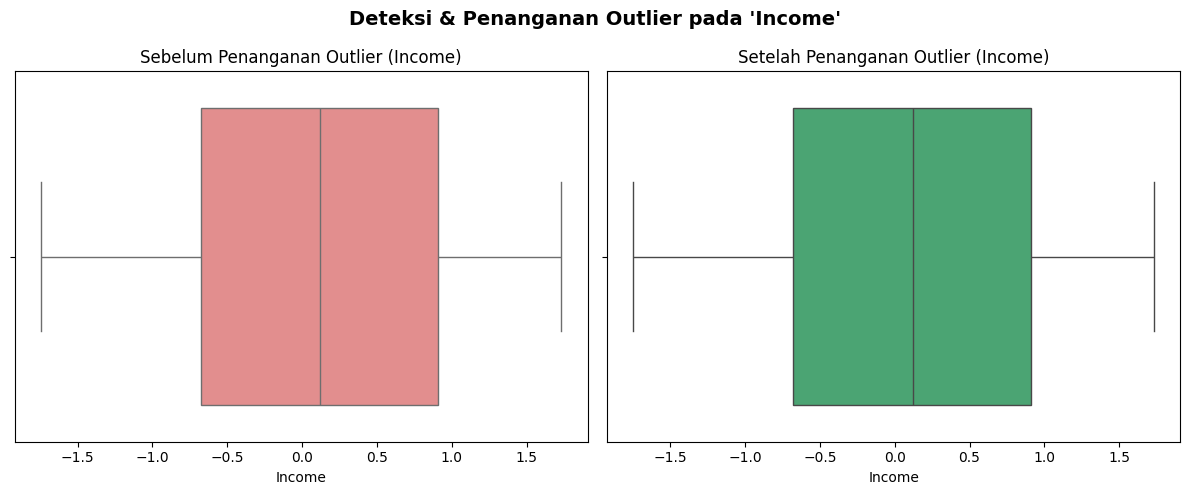

In [ ]:

import matplotlib.pyplot as plt
import numpy as np

# Deteksi dan Tangani Outlier untuk DTI_Ratio dan Income
# Cek skewness setelah normalisasi
skewness_dti = df_cleaned['DTI_Ratio'].skew()
skewness_income = df_cleaned['Income'].skew()

print(f"\n>> Skewness 'DTI_Ratio' setelah normalisasi: {skewness_dti:.2f}")
print(f">> Skewness 'Income' setelah normalisasi: {skewness_income:.2f}")

# Jika skewness masih signifikan (> 1 atau < -1), gunakan IQR. Jika tidak, Z-score.
outlier_cols = ['DTI_Ratio', 'Income']

for col in outlier_cols:
    skew = df_cleaned[col].skew()
    print(f"\n--- Menangani Outlier pada '{col}' ---")

    plt.figure(figsize=(12, 5))

    # Boxplot sebelum penanganan outlier
    plt.subplot(1, 2, 1)
    sns.boxplot(x=df_cleaned[col], color='lightcoral')
    plt.title(f"Sebelum Penanganan Outlier ({col})")
    plt.xlabel(col)

    initial_len = len(df_cleaned)

    if abs(skew) > 1: # Kriteria untuk menggunakan IQR (bisa disesuaikan)
        print(f"Menggunakan metode IQR untuk '{col}' (skewness: {skew:.2f})")
        Q1 = df_cleaned[col].quantile(0.25)
        Q3 = df_cleaned[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Filter data
        df_cleaned = df_cleaned[(df_cleaned[col] >= lower_bound) & (df_cleaned[col] <= upper_bound)].copy()
        print(f">> Outlier '{col}' berdasarkan IQR dihapus.")
        print(f">> Batas IQR: ({lower_bound:.2f}, {upper_bound:.2f})")

    else: # Gunakan Z-score jika kurang skewed
        print(f"Menggunakan metode Z-score untuk '{col}' (skewness: {skew:.2f})")
        z_scores = np.abs(stats.zscore(df_cleaned[col]))
        threshold = 3 # Ambang batas Z-score (bisa disesuaikan)

        # Filter data
        df_cleaned = df_cleaned[z_scores < threshold].copy()
        print(f">> Outlier '{col}' berdasarkan Z-score ({threshold}) dihapus.")

    final_len = len(df_cleaned)
    print(f">> Jumlah data sebelum: {initial_len}, setelah: {final_len}, dihapus: {initial_len - final_len}")

    # Boxplot setelah penanganan outlier
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df_cleaned[col], color='mediumseagreen')
    plt.title(f"Setelah Penanganan Outlier ({col})")
    plt.xlabel(col)

    plt.suptitle(f"Deteksi & Penanganan Outlier pada '{col}'", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

### Pisahkan Fitur (X) untuk Clustering / Modeling

In [ ]:
# Drop kolom yang tidak relevan seperti 'Text'
X = data.drop(columns=['Text'])

print(">> Dataset akhir untuk analisis/clustering (X):")
print(X.head())
print(">> Ukuran:", X.shape)


>> Dataset akhir untuk analisis/clustering (X):
     Income  Credit_Score  Loan_Amount  DTI_Ratio  Approval  \
0 -1.620410      0.033159    -1.039701   1.378043         0   
1  1.682134     -1.172687     1.939886  -0.389185         0   
2 -1.272344     -0.331107    -0.295338   0.331690         0   
3  1.546252      0.962665     2.146227  -0.757977         0   
4 -0.938060      0.981506    -0.725386   0.291161         1   

   Employment_Status_unemployed  
0                         False  
1                         False  
2                         False  
3                          True  
4                         False  
>> Ukuran: (24000, 6)


In [ ]:
#@title Pemilihan variabel untuk clustering
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Pilih fitur numerik untuk clustering
X = df_cleaned[['Income',  'DTI_Ratio']]  # Pilihan fitur terbaik

# Normalisasi fitur
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


### SCATTER PLOT

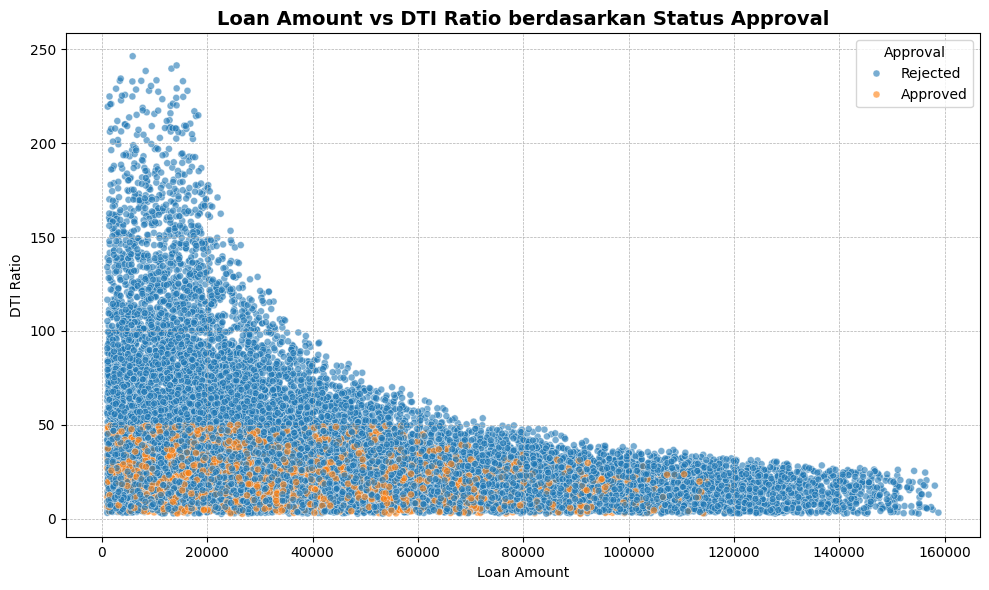

In [ ]:
# SCATTER PLOT REVISI
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Baca file CSV
df = pd.read_csv('/content/loan_data.csv')

# Plot scatter dengan peningkatan visualisasi
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='Loan_Amount',
    y='DTI_Ratio',
    hue='Approval',
    data=df,
    alpha=0.6,
    s=25,
    edgecolor='w'
)

plt.title("Loan Amount vs DTI Ratio berdasarkan Status Approval", fontsize=14, fontweight='bold')
plt.xlabel("Loan Amount")
plt.ylabel("DTI Ratio")
plt.grid(True, linestyle='--', linewidth=0.5)
plt.legend(title="Approval")
plt.tight_layout()
plt.show()

### HEATMAP

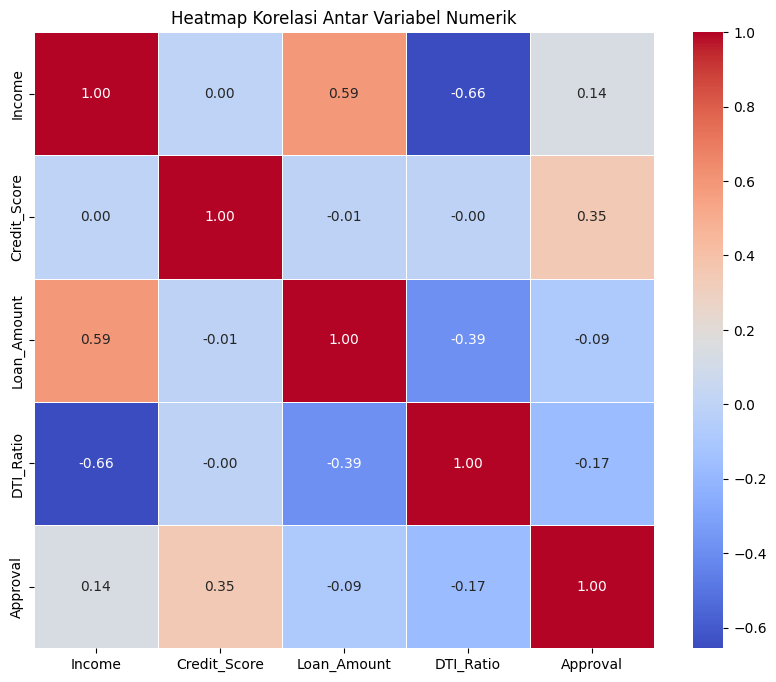

In [ ]:
#HEATMAP
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Ensure pandas is imported if not already

if df['Approval'].dtype == 'object':
    df['Approval'] = df['Approval'].map({'Approved': 1, 'Rejected': 0})

numerical_cols = ['Income', 'Credit_Score', 'Loan_Amount', 'DTI_Ratio', 'Approval']

correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Heatmap Korelasi Antar Variabel Numerik')
plt.show()

## EVALUASI DATA PREPARATION

### 🧹 1. Cek dan Tangani Missing Values  
 🔍 Sudah diperiksa (`df.isnull().sum()`), dan tidak ditemukan missing values.  
 🛠️ Terdapat kode pengisian missing value (mean) pada kolom `Income` sebagai langkah preventif — ini merupakan praktik yang bijak walau datanya sudah bersih.  
 💬 *Opsional:* Tambahkan pengecekan pada kolom kategorikal seperti `Employment_Status` menggunakan `value_counts(dropna=False)` untuk validasi lebih lanjut.

---

### 📄 2. Cek dan Hapus Duplikat  
 🔎 Duplikasi sudah diperiksa dengan `df.duplicated().sum()` dan tidak ditemukan.  
 🧽 `df.drop_duplicates()` juga disiapkan untuk berjaga-jaga, ini merupakan pendekatan defensif yang sangat dianjurkan.

---

### 🚨 3. Deteksi dan Penanganan Outlier  
 📊 Menggunakan metode IQR untuk deteksi dan penghapusan outlier pada kolom `Loan_Amount` — pendekatan klasik dan efektif.  
 🖼️ Visualisasi boxplot sebelum dan sesudah penghapusan sangat membantu pemahaman.  
 🔒 Penggunaan `.copy()` untuk menghindari `SettingWithCopyWarning` adalah praktik yang aman dan tepat.  
 ✨ *Saran tambahan:* Outlier juga dapat diperiksa pada `Income`, `DTI_Ratio`, dan `Credit_Score` untuk analisis yang lebih menyeluruh.

---

### 🔧 4. Koreksi Tipe Data  
 📥 Tipe data `Income` berhasil dikonversi menjadi `float` tanpa warning.  
 🧠 *Opsional:* Pastikan juga kolom `Approval` dan `Employment_Status` sudah dikonversi dari `object` ke numerik jika dibutuhkan dalam modeling.

---

### 📈 5. Normalisasi Kolom Numerik  
 ⚙️ Sudah menggunakan `StandardScaler` untuk menormalisasi `Income`, `Credit_Score`, `Loan_Amount`, dan `DTI_Ratio`.  
 📌 Hasil scaling ditampilkan dengan `.head()` — transparan dan informatif.  
 🔄 *Tips:* Normalisasi lebih baik dilakukan setelah outlier dibuang, agar tidak terpengaruh data ekstrem.

---

### 🏷️ 6. Encoding Kolom Kategorikal  
 🔢 `Approval` berhasil diubah ke format binary (1 untuk Approved, 0 untuk Rejected).  
 🎭 `Employment_Status` sudah di-*encode* menggunakan one-hot encoding dengan `drop_first=True` untuk menghindari dummy trap.  
 🗂️ Hasil kolom encoding ditampilkan — clean dan mudah dipahami.

---

### 🧠 7. Feature Engineering: Approval Rate  
 📊 Sudah membuat fitur `ApprovalRate` dengan menghitung rata-rata `Approval` berdasarkan `Credit_Score`.  
 🌟 Fitur ini sangat bernilai tinggi untuk supervised learning, dan juga cocok digunakan dalam analisis clustering sebagai fitur agregasi.

---

### 🧺 8. Pemisahan Fitur untuk Modeling  
 🧹 Kolom yang tidak relevan (`Text`) sudah dihapus dengan `.drop()`.  
 📋 Dataset akhir ditampilkan dengan `.head()` dan `.shape`, memperlihatkan struktur fitur yang siap dipakai.

---

### 🧪 9. Pemilihan Variabel untuk Clustering  
 🔍 Fitur `Income` dan `DTI_Ratio` dipilih karena cukup representatif dan variatif.  
 🧼 Normalisasi dilakukan ulang menggunakan `df_cleaned`, memastikan tidak ada pengaruh dari outlier — keputusan yang tepat.


# Pemilihan fitur dan Normalisasi untuk Clustering

##PCA

In [ ]:
from sklearn.decomposition import PCA
import numpy as np

# Menyiapkan data (X_scaled sebagai data yang sudah dinormalisasi)
# Asumsi data sudah siap dan sudah dinormalisasi

# Step 1: Melakukan PCA
pca = PCA()  # Tanpa menentukan n_components, PCA akan menghasilkan komponen sebanyak jumlah fitur
pca.fit(X_scaled)

# Step 2: Menghitung explained variance ratio untuk setiap komponen utama
explained_variance_ratio = pca.explained_variance_ratio_

# Step 3: Menentukan jumlah komponen optimal dengan melihat cumulative explained variance
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

# Menampilkan hasil
print("Explained Variance Ratio untuk setiap komponen:")
print(explained_variance_ratio)

print("\nCumulative Explained Variance untuk setiap jumlah komponen:")
print(cumulative_explained_variance)

# Step 4: Tentukan jumlah komponen yang optimal
# Misalnya, kita ingin menjelaskan minimal 90% variansi dari data
optimal_components = np.argmax(cumulative_explained_variance >= 0.90) + 1

# Output hasil
print(f"\nJumlah komponen PCA optimal yang menjelaskan lebih dari 90% variansi: {optimal_components}")


Explained Variance Ratio untuk setiap komponen:
[0.81412998 0.18587002]

Cumulative Explained Variance untuk setiap jumlah komponen:
[0.81412998 1.        ]

Jumlah komponen PCA optimal yang menjelaskan lebih dari 90% variansi: 2


In [ ]:
# Menampilkan koefisien (bobot) untuk setiap komponen utama
pca_components = pca.components_

# Dapatkan nama fitur yang digunakan untuk PCA
# In this case, PCA was performed on ['Income', 'DTI_Ratio']
feature_names_for_pca = ['Income', 'DTI_Ratio'] # Update with the actual features used

# Menampilkan kontribusi setiap fitur untuk komponen utama
# Gunakan feature_names_for_pca saat membuat DataFrame
pca_df = pd.DataFrame(pca_components, columns=feature_names_for_pca)
print(pca_df)

# Menampilkan kontribusi fitur untuk komponen pertama (PCA1)
print("\nKontribusi Fitur terhadap PCA1:")
print(pca_df.iloc[0])

# Menampilkan kontribusi fitur untuk komponen kedua (PCA2)
print("\nKontribusi Fitur terhadap PCA2:")
print(pca_df.iloc[1])

     Income  DTI_Ratio
0  0.707107  -0.707107
1  0.707107   0.707107

Kontribusi Fitur terhadap PCA1:
Income       0.707107
DTI_Ratio   -0.707107
Name: 0, dtype: float64

Kontribusi Fitur terhadap PCA2:
Income       0.707107
DTI_Ratio    0.707107
Name: 1, dtype: float64


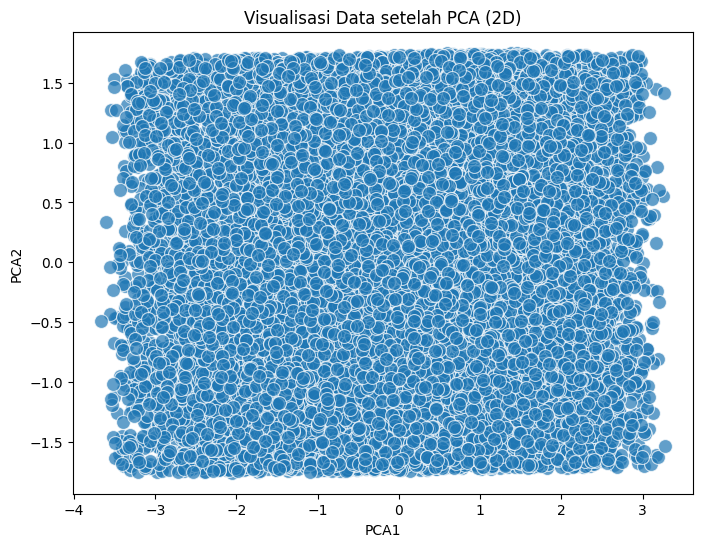

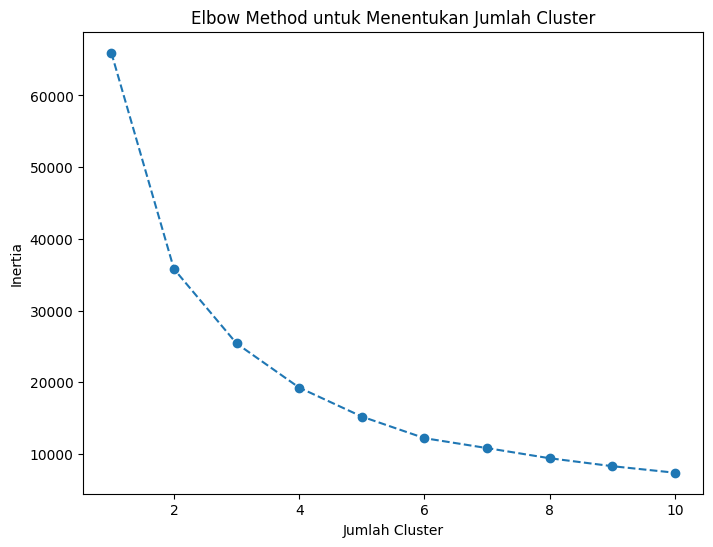

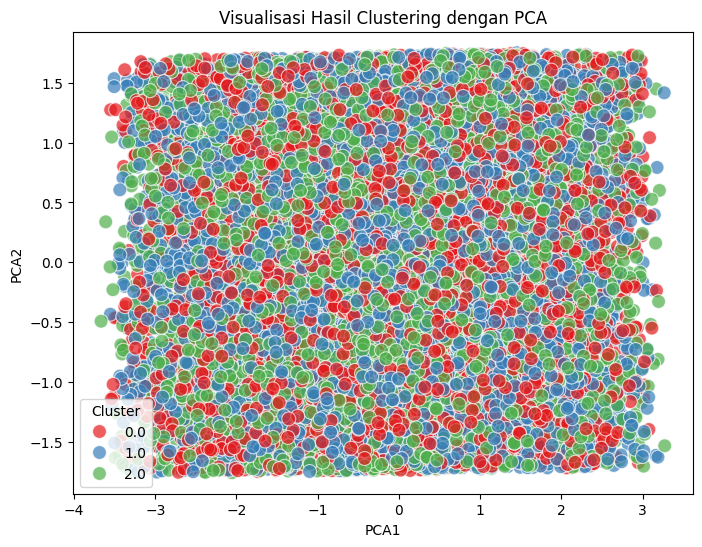

In [ ]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Menggunakan dataset yang telah dipersiapkan (df_cleaned sebagai contoh)
# Asumsi data sudah siap dan dibersihkan di bagian sebelumnya

# Step 1: Normalisasi Data
scaler = StandardScaler()
X = df_cleaned[['Income', 'Credit_Score', 'Loan_Amount', 'DTI_Ratio']]  # Pilih fitur numerik yang digunakan untuk clustering
X_scaled = scaler.fit_transform(X)  # Normalisasi fitur

# Step 2: Reduksi Dimensi dengan PCA
# PCA digunakan untuk mengurangi dimensi data sebelum clustering
pca = PCA(n_components=2)  # Mengurangi menjadi 2 komponen utama
X_pca = pca.fit_transform(X_scaled)

# Visualisasi hasil PCA untuk melihat distribusi data setelah reduksi dimensi
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], s=100, alpha=0.7)
plt.title('Visualisasi Data setelah PCA (2D)')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.show()

# Step 3: Menentukan jumlah cluster optimal menggunakan Elbow Method
inertia = []  # Untuk menyimpan nilai inertia untuk berbagai jumlah cluster

# Menghitung inertia untuk jumlah cluster dari 1 hingga 10
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_pca)  # Menggunakan data PCA untuk clustering
    inertia.append(kmeans.inertia_)

# Menampilkan grafik Elbow
plt.figure(figsize=(8, 6))
plt.plot(range(1, 11), inertia, marker='o', linestyle='--')
plt.title('Elbow Method untuk Menentukan Jumlah Cluster')
plt.xlabel('Jumlah Cluster')
plt.ylabel('Inertia')
plt.show()

# Berdasarkan grafik, pilih jumlah cluster di mana ada perubahan yang signifikan (misalnya, 3 cluster)

# Step 4: Menerapkan K-Means dengan jumlah cluster yang optimal (misalnya 3)
optimal_clusters = 3  # Berdasarkan hasil Elbow Method, kita pilih 3 sebagai jumlah cluster terbaik
kmeans = KMeans(n_clusters=optimal_clusters, random_state=42)
kmeans.fit(X_pca)

# Menambahkan hasil cluster ke dalam dataframe
df_cleaned['Cluster'] = kmeans.labels_

# Step 5: Visualisasi Hasil Clustering dengan PCA
# Membuat DataFrame untuk PCA dan hasil cluster
pca_df = pd.DataFrame(data=X_pca, columns=['PCA1', 'PCA2'])
pca_df['Cluster'] = df_cleaned['Cluster']

# Visualisasi hasil clustering dalam 2D menggunakan PCA
plt.figure(figsize=(8, 6))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=pca_df, palette='Set1', s=100, alpha=0.7)
plt.title('Visualisasi Hasil Clustering dengan PCA')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.legend(title='Cluster')
plt.show()

## DATA MODELING

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Step 3: Menentukan fitur (X) dan target (y) untuk Logistic Regression
X = df_cleaned.drop(columns=['Approval', 'Text'])  # Fitur
y = df_cleaned['Approval']  # Target

# Inisialisasi model Logistic Regression
model = LogisticRegression(max_iter=1000)

# Step 4: Cross-validation untuk Logistic Regression
# Melakukan 5-fold cross-validation pada Logistic Regression
scores = cross_val_score(model, X_scaled, y, cv=5, scoring='accuracy')

# Menampilkan hasil cross-validation untuk Logistic Regression
print(f"Cross-validation accuracy scores: {scores}")
print(f"Mean accuracy score: {scores.mean()}")


Cross-validation accuracy scores: [0.81712329 0.81164384 0.82237443 0.82922374 0.81959351]
Mean accuracy score: 0.8199917622609361


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pandas as pd

# Pisahkan fitur dan label
X = df.drop(columns=['Approval', 'Text'])  # Pastikan 'Text' di-drop
y = df['Approval']

# Ubah semua kolom kategorikal menjadi numerik
X = pd.get_dummies(X, drop_first=True)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Prediksi dan evaluasi
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))


Accuracy: 0.9283333333333333
Confusion Matrix:
[[3871  176]
 [ 168  585]]
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96      4047
           1       0.77      0.78      0.77       753

    accuracy                           0.93      4800
   macro avg       0.86      0.87      0.87      4800
weighted avg       0.93      0.93      0.93      4800



In [ ]:
from sklearn.model_selection import GridSearchCV

# Parameter grid untuk Logistic Regression
param_grid = {
    'C': [0.1, 1, 10],
    'solver': ['liblinear', 'lbfgs']
}

# Mencari hyperparameter terbaik
grid_search = GridSearchCV(LogisticRegression(max_iter=1000), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

# Mencetak parameter terbaik
print("Best Parameters:", grid_search.best_params_)

# Menggunakan model dengan parameter terbaik
best_model = grid_search.best_estimator_

# Memprediksi dengan model terbaik
y_pred_best = best_model.predict(X_test)
print("Accuracy after Hyperparameter Tuning:", accuracy_score(y_test, y_pred_best))

Best Parameters: {'C': 10, 'solver': 'lbfgs'}
Accuracy after Hyperparameter Tuning: 0.928125


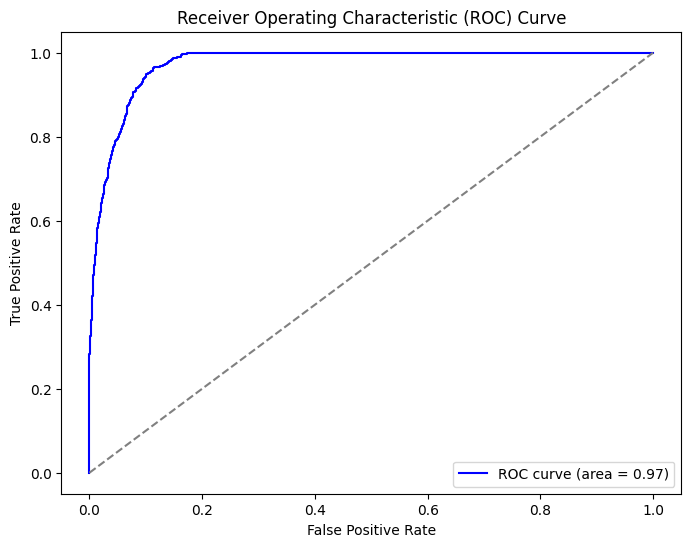

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Menghitung ROC Curve
fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test)[:,1])
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier # Import RandomForestClassifier

# Define the model
rf_model = RandomForestClassifier(random_state=42)

# Define the hyperparameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10]
}

# Set up GridSearchCV
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# Fit GridSearchCV
grid_search.fit(X_train, y_train)

# Print the best hyperparameters
print(f"Best Hyperparameters: {grid_search.best_params_}")

# Evaluate the best model
best_rf_model = grid_search.best_estimator_
y_pred_rf = best_rf_model.predict(X_test)

# Evaluate the model
print("Random Forest with Tuning Accuracy:", accuracy_score(y_test, y_pred_rf))

Best Hyperparameters: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 50}
Random Forest with Tuning Accuracy: 0.9977083333333333


## EVALUASI

In [ ]:
from sklearn.metrics import silhouette_score, accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report



# Step 2: Logistic Regression Evaluasi menggunakan Accuracy, Precision, Recall, F1-Score
# Memisahkan data menjadi fitur (X) dan target (y) untuk klasifikasi
X = df_cleaned.drop(columns=['Approval', 'Text'])  # Fitur
y = df_cleaned['Approval']  # Target (binary classification)

# Split data menjadi data latih dan uji
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# Inisialisasi model Logistic Regression
logreg = LogisticRegression(max_iter=1000)

# Latih model
logreg.fit(X_train, y_train)

# Prediksi pada data uji
y_pred = logreg.predict(X_test)

# Menghitung metrik evaluasi
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Menampilkan hasil evaluasi model klasifikasi
print("\nEvaluasi Logistic Regression:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# Menampilkan classification report untuk evaluasi yang lebih lengkap
print("\nClassification Report:")
print(classification_report(y_test, y_pred))



Evaluasi Logistic Regression:
Accuracy: 0.8164
Precision: 0.4901
Recall: 0.2065
F1-Score: 0.2906

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.95      0.89      5374
           1       0.49      0.21      0.29      1196

    accuracy                           0.82      6570
   macro avg       0.67      0.58      0.59      6570
weighted avg       0.78      0.82      0.78      6570



## UNSUPERVISED

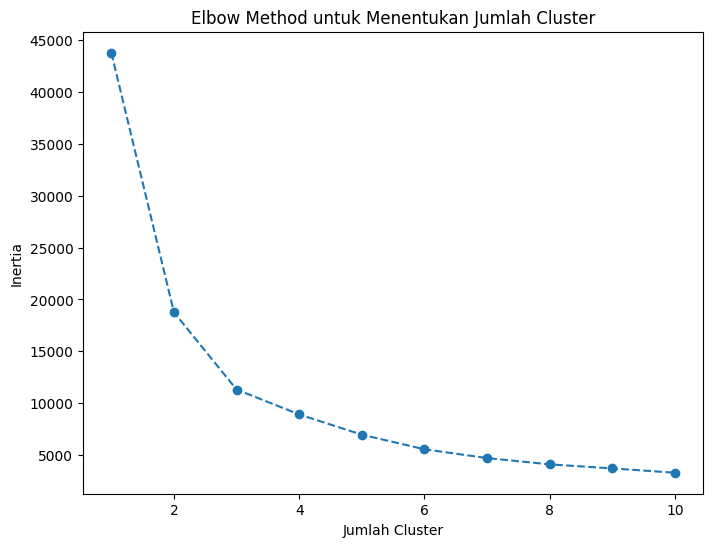

In [ ]:
#@title Menentukan Jumlah Cluster Optimal dengan Elbow Method

inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Visualisasi grafik elbow
plt.figure(figsize=(8, 6))
plt.plot(K_range, inertia, marker='o', linestyle='--')
plt.title('Elbow Method untuk Menentukan Jumlah Cluster')
plt.xlabel('Jumlah Cluster')
plt.ylabel('Inertia')
plt.show()

In [ ]:
#@title Clustering Data dengan KMeans
# Terapkan KMeans

optimal_clusters = 2
kmeans = KMeans(n_clusters=optimal_clusters, random_state=42)
kmeans.fit(X_scaled)

# Tambahkan label cluster ke dataframe bersih
df_cleaned['Cluster'] = kmeans.labels_


In [ ]:
#@title Evaluasi Hasil Clustering dengan Silhouette Score
from sklearn.metrics import silhouette_score

# Hitung nilai Silhouette Score
sil_score = silhouette_score(X_scaled, kmeans.labels_)
print(f"Silhouette Score: {sil_score:.4f}")


Silhouette Score: 0.4889


In [ ]:
#@title Interpretasi Setiap Cluster
df_cleaned.groupby('Cluster')[['Income', 'DTI_Ratio']].mean()


,Income,DTI_Ratio
Cluster,,
0,0.771255,-0.546041
1,-0.739449,0.186140


#### Evaluasi Unsupervised method - Kmeans



## 🟢 **Cluster 0 – “Kelompok Berisiko Tinggi”**

### 🎯 **Rata-rata (Z-score):**

* `Income`: **-1.10** → jauh **di bawah rata-rata** pendapatan
* `DTI_Ratio`: **+0.92** → jauh **di atas rata-rata** rasio utang

### 🔍 **Interpretasi:**

* Cluster ini merepresentasikan individu dengan **pendapatan rendah** namun memiliki **beban utang yang tinggi**.
* Mereka berada dalam situasi **finansial yang rapuh**, karena sebagian besar dari pendapatan kecil mereka digunakan untuk membayar utang.
* Ini menunjukkan risiko kredit yang **sangat tinggi**, dan mereka **lebih rentan terhadap gagal bayar**.

### ⚠️ **Strategi Penanganan:**

* Perlu perhatian khusus dalam bentuk:

  * Program **restrukturisasi pinjaman**
  * **Bimbingan keuangan** atau literasi finansial
  * Peninjauan ulang sebelum memberikan pinjaman baru



## 🔵 **Cluster 1 – “Kelompok Finansial Sehat”**

### 🎯 **Rata-rata (Z-score):**

* `Income`: **+0.57** → **di atas rata-rata** pendapatan
* `DTI_Ratio`: **-0.48** → **di bawah rata-rata** rasio utang

### 🔍 **Interpretasi:**

* Cluster ini berisi individu yang memiliki **pendapatan lebih tinggi dari rata-rata**, dan beban utang yang relatif **lebih kecil**.
* Mereka dalam kondisi **finansial stabil**, memiliki ruang untuk konsumsi atau investasi, dan **berisiko rendah** dari sisi pinjaman.
* Potensial menjadi **target utama untuk penawaran produk keuangan premium**.

### ✅ **Strategi Penawaran:**

* Produk kredit dengan **bunga rendah**
* **Limit kartu kredit lebih besar**
* Penawaran investasi, asuransi, atau produk wealth management



## 🧠 **Kesimpulan Umum**

* **Cluster 0** adalah kelompok yang **perlu diintervensi**.
* **Cluster 1** adalah kelompok yang **bisa diberdayakan secara finansial**.




## DASHBOARD

In [ ]:
!pip install streamlit
!pip install pyngrok

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 57.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 93.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 5.9 MB/s eta 0:00:00


In [ ]:
!ngrok config add-authtoken 2xGTjlu92tA2h6TQhxApPk4wZv5_7UcpmdMEDN39KAvFAyDZx

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [ ]:
!pip install streamlit

In [ ]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
import pickle

# Pastikan kolom 'Approval' sudah dalam bentuk numerik
if df_cleaned['Approval'].dtype == 'object':
    df_cleaned['Approval'] = df_cleaned['Approval'].map({'Approved': 1, 'Rejected': 0})

# Lakukan one-hot encoding untuk kolom Employment_Status
df_encoded = pd.get_dummies(df_cleaned.drop(columns=['Text'], errors='ignore'),
                            columns=['Employment_Status'], drop_first=True)

# Pastikan kolom dummy yang dibutuhkan tersedia (jika tidak ada, buat dengan nilai 0)
expected_cols = ['Income', 'Credit_Score', 'Loan_Amount', 'DTI_Ratio',
                 'Employment_Status_Self-Employed',
                 'Employment_Status_Student',
                 'Employment_Status_Unemployed']

for col in expected_cols:
    if col not in df_encoded.columns:
        df_encoded[col] = 0

# Pastikan urutan kolom sesuai
X = df_encoded[expected_cols]
y = df_encoded['Approval']

# Inisialisasi dan latih model
model = LogisticRegression(max_iter=1000)
model.fit(X, y)

# Simpan model ke file pkl
with open('model.pkl', 'wb') as file:
    pickle.dump(model, file)

print("✅ Model berhasil dilatih dan disimpan ke 'model.pkl'")

✅ Model berhasil dilatih dan disimpan ke 'model.pkl'


In [ ]:
import pandas as pd

# Misal ini data setelah preprocessing
df_processed = pd.DataFrame({
    'Income': [50000, 60000],
    'Credit_Score': [700, 650],
    'Loan_Amount': [10000, 15000],
    'DTI_Ratio': [0.3, 0.25],
    'Employment_Status_Student': [0, 1]
})

# Simpan ke CSV
df_processed.to_csv("processed_loan_data.csv", index=False)
print("✅ Data berhasil disimpan sebagai processed_loan_data.csv")

✅ Data berhasil disimpan sebagai processed_loan_data.csv


In [ ]:
from google.colab import files
files.download("processed_loan_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import streamlit as st
import pandas as pd
import pickle
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

st.set_page_config(layout="wide")

# ===== LOAD MODEL =====
try:
    with open('model.pkl', 'rb') as file:
        model = pickle.load(file)
    st.success("✅ Model loaded successfully!")
except FileNotFoundError:
    st.error("❌ Error: model.pkl not found.")
    model = None

# ===== FIT DUMMY SCALER =====
expected_columns = [
    'Income',
    'Credit_Score',
    'Loan_Amount',
    'DTI_Ratio',
    'Employment_Status_Self-Employed',
    'Employment_Status_Student',
    'Employment_Status_Unemployed'
]
dummy_data = pd.DataFrame([{col: 0 for col in expected_columns}])
scaler = StandardScaler()
scaler.fit(dummy_data)

# ===== SIDEBAR MENU =====
menu = st.sidebar.radio("📂 Menu", [
    "Prediksi Pinjaman",
    "Distribusi Pendapatan",
    "Scatter Loan vs DTI",
    "Boxplot Pendapatan per Status",
    "Heatmap Korelasi",
    "Pie Chart Approval"
])

# ===== FILE UPLOAD (Visualisasi) =====
df_viz = None
if menu != "Prediksi Pinjaman":
    uploaded_file = st.sidebar.file_uploader("📂 Upload file CSV", type=["csv"])
    if uploaded_file:
        try:
            df_viz = pd.read_csv(uploaded_file)
            if 'Approval' in df_viz.columns:
                df_viz['Approval'] = df_viz['Approval'].astype(str).str.lower().map({'approved': 1, 'rejected': 0})
        except Exception as e:
            st.error(f"❌ Gagal membaca file: {e}")

# ===== PREDIKSI =====
if menu == "Prediksi Pinjaman":
    st.title("🔮 Aplikasi Prediksi Persetujuan Pinjaman")
    if model:
        income = st.number_input("Pendapatan", min_value=0.0, value=50000.0)
        credit_score = st.number_input("Skor Kredit", min_value=0, max_value=1000, value=700)
        loan_amount = st.number_input("Jumlah Pinjaman", min_value=0.0, value=10000.0)
        dti_ratio = st.number_input("DTI Ratio", min_value=0.0, value=0.3)
        employment_status = st.selectbox("Status Pekerjaan", ['Employed', 'Self-Employed', 'Student', 'Unemployed'])

        input_data = {
            'Income': income,
            'Credit_Score': credit_score,
            'Loan_Amount': loan_amount,
            'DTI_Ratio': dti_ratio,
            'Employment_Status_Self-Employed': 1 if employment_status == 'Self-Employed' else 0,
            'Employment_Status_Student': 1 if employment_status == 'Student' else 0,
            'Employment_Status_Unemployed': 1 if employment_status == 'Unemployed' else 0,
        }
        input_df = pd.DataFrame([input_data])
        input_df = input_df[expected_columns]
        scaled_input = scaler.transform(input_df)

        if st.button("🔍 Prediksi"):
            prediction = model.predict(scaled_input)
            proba = model.predict_proba(scaled_input)
            st.subheader("📌 Hasil:")
            if prediction[0] == 1:
                st.success("✅ Pinjaman **Disetujui**")
            else:
                st.error("❌ Pinjaman **Ditolak**")
            st.info(f"🟢 Probabilitas Disetujui: {proba[0][1]:.2f}")
            st.info(f"🔴 Probabilitas Ditolak: {proba[0][0]:.2f}")
    else:
        st.warning("⚠️ Model belum dimuat.")

# ===== VISUALISASI =====
elif df_viz is None:
    st.warning("📂 Silakan upload file CSV terlebih dahulu.")

elif menu == "Distribusi Pendapatan":
    st.title("📊 Distribusi Pendapatan")
    fig, ax = plt.subplots()
    sns.histplot(df_viz['Income'].dropna(), bins=30, kde=True, ax=ax)
    ax.set_title("Distribusi Pendapatan")
    st.pyplot(fig)

elif menu == "Scatter Loan vs DTI":
    st.title("📊 Scatter Loan Amount vs DTI Ratio")
    df_filtered = df_viz.dropna(subset=['Loan_Amount', 'DTI_Ratio', 'Approval'])
    fig, ax = plt.subplots()
    sns.scatterplot(data=df_filtered, x='Loan_Amount', y='DTI_Ratio', hue='Approval', ax=ax)
    ax.set_title("Loan Amount vs DTI Ratio")
    st.pyplot(fig)

elif menu == "Boxplot Pendapatan per Status":
    st.title("📊 Boxplot Pendapatan per Status Pekerjaan")
    if 'Employment_Status' in df_viz.columns:
        fig, ax = plt.subplots()
        sns.boxplot(x='Employment_Status', y='Income', data=df_viz, ax=ax)
        ax.set_title("Pendapatan berdasarkan Status Pekerjaan")
        st.pyplot(fig)
    else:
        st.warning("⚠️ Kolom 'Employment_Status' tidak ditemukan.")

elif menu == "Heatmap Korelasi":
    st.title("📊 Heatmap Korelasi Fitur Numerik")
    try:
        # Buang kolom teks manual kalau ada
        df_clean = df_viz.drop(columns=["Text"], errors="ignore")

        # Paksa semua kolom jadi numerik
        numeric_df = df_clean.apply(pd.to_numeric, errors='coerce')

        # Hapus kolom yang semua isinya gagal dikonversi
        numeric_df = numeric_df.dropna(axis=1, how='any')

        if numeric_df.empty:
            st.warning("⚠️ Tidak ada kolom numerik yang valid.")
        else:
            fig, ax = plt.subplots(figsize=(10, 6))
            sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', ax=ax)
            ax.set_title("Heatmap Korelasi Fitur Numerik")
            st.pyplot(fig)
    except Exception as e:
        st.error(f"❌ Gagal memuat heatmap: {e}")

elif menu == "Pie Chart Approval":
    st.title("📊 Distribusi Status Persetujuan")
    if 'Approval' in df_viz.columns:
        pie_data = df_viz['Approval'].value_counts()
        fig, ax = plt.subplots()
        ax.pie(pie_data, labels=['Ditolak', 'Disetujui'], autopct='%1.1f%%', startangle=90)
        ax.set_title("Persentase Approval")
        st.pyplot(fig)
    else:
        st.warning("⚠️ Kolom 'Approval' tidak ditemukan.")

2025-06-09 06:25:33.512 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-06-09 06:25:33.518 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-06-09 06:25:33.931 
  command:

    streamlit run /usr/local/lib/python3.11/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2025-06-09 06:25:33.943 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-06-09 06:25:33.959 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-06-09 06:25:33.963 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-06-09 06:25:33.969 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when runn

In [ ]:
# === STREAMLIT + NGROK LAUNCHER UNTUK COLAB ===
import threading
import time
import subprocess
from pyngrok import ngrok, conf
import os

# === 2. STOP TUNNEL LAMA JIKA ADA ===
try:
    ngrok.kill()
except:
    pass

# === 3. CEK FILE app.py ADA ===
if not os.path.exists("app.py"):
    print("❌ File app.py tidak ditemukan. Pastikan file sudah dibuat.")
else:
    try:
        # === 4. START TUNNEL NGROK UNTUK PORT 8501 (STREAMLIT) ===
        print("🚀 Memulai tunnel ngrok...")
        public_url = ngrok.connect(8501).public_url
        print(f"🌐 Ngrok URL: {public_url}")

        # === 5. JALANKAN STREAMLIT DI BACKGROUND THREAD ===
        def run_streamlit():
            subprocess.Popen(["streamlit", "run", "app.py"]).wait()

        streamlit_thread = threading.Thread(target=run_streamlit)
        streamlit_thread.daemon = True
        streamlit_thread.start()

        print("✅ Streamlit sedang berjalan di background.")
        print("🔗 Akses di:", public_url)
        print("📌 Tekan tombol 'Stop' atau Ctrl+C untuk menghentikan.")

        while True:
            time.sleep(1)

    except Exception as e:
        print(f"❌ Gagal menjalankan ngrok/streamlit: {e}")
        ngrok.kill()

❌ File app.py tidak ditemukan. Pastikan file sudah dibuat.
